# Knowledge Graph XAI System for CFRP Composites

This notebook demonstrates the Knowledge Graph-based Explainable AI system for RUL prediction in CFRP composite materials.

## Contents:
1. Load trained models
2. Build and visualize Knowledge Graph
3. Generate explanations for predictions
4. Compare model explanations
5. Interactive exploration

In [1]:
# Import required libraries
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

# Add parent directory to path
sys.path.insert(0, os.path.abspath('..'))

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Import custom modules
from modules import CFRPKnowledgeGraph, XAIExplainer


Using device: cpu


## 1. Build Knowledge Graph

Create the domain knowledge graph for CFRP composite degradation.

In [2]:
# Build Knowledge Graph
kg = CFRPKnowledgeGraph()

# Print graph statistics
print("Knowledge Graph Statistics:")
print(f"  Nodes: {kg.graph.number_of_nodes()}")
print(f"  Edges: {kg.graph.number_of_edges()}")
print("\nNode Types:")
for node_type in ['feature', 'phenomenon', 'stage']:
    nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == node_type]
    print(f"  {node_type.capitalize()}s: {len(nodes)}")
    for node in nodes:
        print(f"    - {node}")

Knowledge Graph Statistics:
  Nodes: 15
  Edges: 12

Node Types:
  Features: 6
    - delta_psd
    - energy
    - tof
    - mean_intensity
    - crack_density
    - mean_strain
  Phenomenons: 5
    - crack_propagation
    - delamination
    - matrix_cracking
    - fiber_breakage
    - stiffness_loss
  Stages: 4
    - healthy
    - early_damage
    - progressive
    - critical


## 2. Visualize Knowledge Graph

Visualize the structure of the knowledge graph.

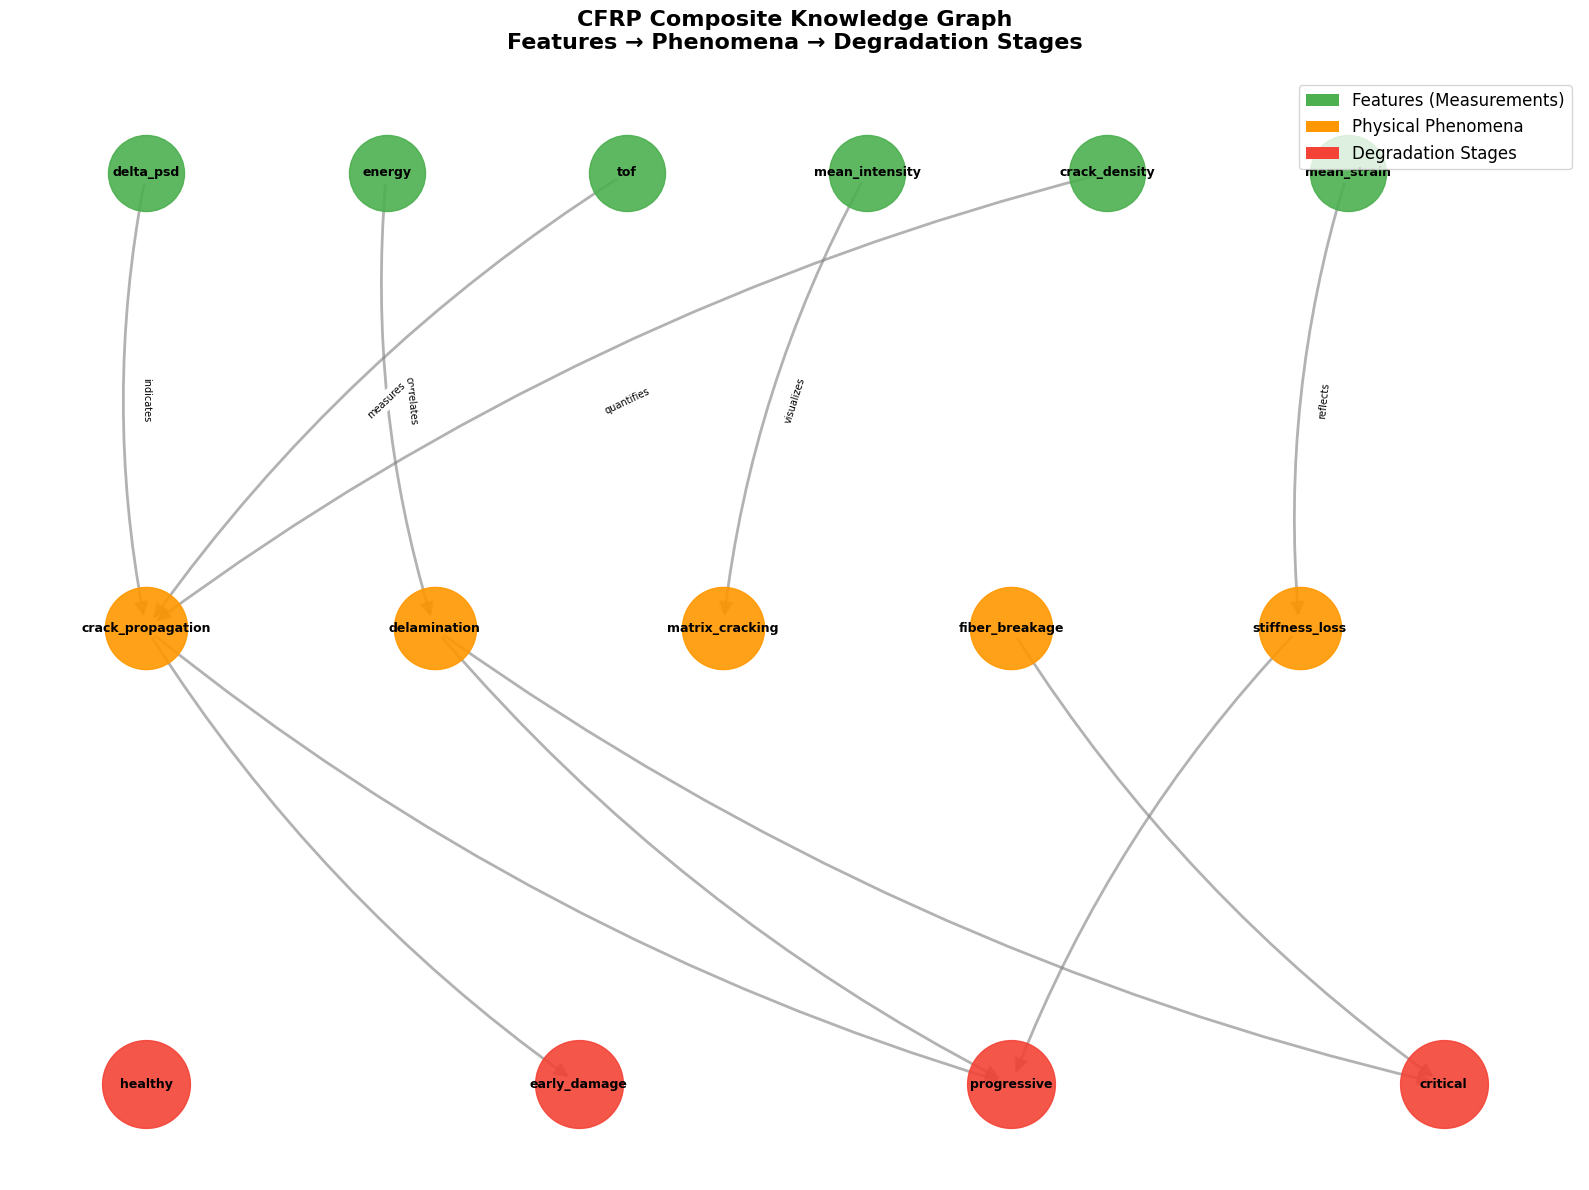

In [3]:
# Visualize Knowledge Graph
fig, ax = plt.subplots(figsize=(16, 12))

# Create hierarchical layout
pos = {}
feature_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'feature']
phenomenon_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'phenomenon']
stage_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'stage']

# Position nodes in layers
y_levels = {'feature': 0, 'phenomenon': -3, 'stage': -6}
for i, node in enumerate(feature_nodes):
    pos[node] = (i * 2.5, y_levels['feature'])
for i, node in enumerate(phenomenon_nodes):
    pos[node] = (i * 3, y_levels['phenomenon'])
for i, node in enumerate(stage_nodes):
    pos[node] = (i * 4.5, y_levels['stage'])

# Draw nodes by type
node_colors = {'feature': '#4CAF50', 'phenomenon': '#FF9800', 'stage': '#F44336'}
node_sizes = {'feature': 3000, 'phenomenon': 3500, 'stage': 4000}

for node_type in ['feature', 'phenomenon', 'stage']:
    nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == node_type]
    nx.draw_networkx_nodes(kg.graph, pos, nodelist=nodes,
                          node_color=node_colors[node_type],
                          node_size=node_sizes[node_type],
                          alpha=0.9, ax=ax)

# Draw edges with arrows
nx.draw_networkx_edges(kg.graph, pos, edge_color='gray',
                      arrows=True, arrowsize=20, width=2,
                      alpha=0.6, ax=ax, connectionstyle='arc3,rad=0.1')

# Draw labels
nx.draw_networkx_labels(kg.graph, pos, font_size=9, font_weight='bold', ax=ax)

# Add edge labels (relation types)
edge_labels = nx.get_edge_attributes(kg.graph, 'relation')
nx.draw_networkx_edge_labels(kg.graph, pos, edge_labels, font_size=7, ax=ax)

# Title and legend
ax.set_title('CFRP Composite Knowledge Graph\nFeatures → Phenomena → Degradation Stages',
            fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=node_colors['feature'], label='Features (Measurements)'),
    Patch(facecolor=node_colors['phenomenon'], label='Physical Phenomena'),
    Patch(facecolor=node_colors['stage'], label='Degradation Stages')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

## 3. Load Trained Models and Data

Load the trained models and test data for explanation generation.

In [4]:
# Load models and data
# NOTE: Update these paths based on your saved model locations
import pickle
from sklearn.preprocessing import MinMaxScaler

# Load scalers
with open('../outputs/saved_models/feature_scaler.pkl', 'rb') as f:
    feature_scaler = pickle.load(f)
with open('../outputs/saved_models/target_scaler.pkl', 'rb') as f:
    target_scaler = pickle.load(f)

# Load test data
with open('../outputs/saved_models/test_data.pkl', 'rb') as f:
    test_data = pickle.load(f)
    X_test = test_data['X_test']
    y_test = test_data['y_test']

print(f"Test data loaded: {X_test.shape[0]} samples")
print(f"Sequence length: {X_test.shape[1]}")
print(f"Features: {X_test.shape[2]}")

# Feature names
feature_names = ['delta_psd', 'energy', 'tof', 'mean_intensity', 'crack_density', 'mean_strain']

Test data loaded: 60 samples
Sequence length: 5
Features: 20


In [13]:
# Load All Models (Transformer, LSTM, DDPG)
import sys
sys.path.insert(0, '../src')
from modules.model_architecture import TransformerRULPredictor, LSTMRULPredictor
from modules.drl_models import DDPGActor
import torch.nn as nn

# Initialize Transformer and LSTM
transformer_model = TransformerRULPredictor(
    input_dim=20,
    d_model=128,
    nhead=8,
    num_layers=4,
    dropout=0.2
).to(device)

lstm_model = LSTMRULPredictor(
    input_dim=20,
    hidden_dim=128,
    num_layers=3,
    dropout=0.2
).to(device)

# Load weights for Transformer and LSTM
transformer_model.load_state_dict(torch.load('../outputs/saved_models/transformer_model.pth', map_location=device))
lstm_model.load_state_dict(torch.load('../outputs/saved_models/lstm_model.pth', map_location=device))

transformer_model.eval()
lstm_model.eval()

print("✓ Transformer and LSTM models loaded")


# Initialize DDPG Actor
ddpg_model = DDPGActor(input_dim=20, hidden_dim=128).to(device)
ddpg_model.load_state_dict(torch.load('../outputs/saved_models/ddpg_actor.pth', map_location=device))
ddpg_model.eval()
    
print("✓ DDPG model loaded")

print("\n✓ All available models loaded successfully")

✓ Transformer and LSTM models loaded
✓ DDPG model loaded

✓ All available models loaded successfully


## 4. Initialize XAI Explainers

Create explainer instances for both models.

In [14]:
# Create explainers for all models
transformer_explainer = XAIExplainer(transformer_model, kg, feature_names, model_type='standard')
lstm_explainer = XAIExplainer(lstm_model, kg, feature_names, model_type='standard')
ddpg_explainer = XAIExplainer(ddpg_model, kg, feature_names, model_type='ddpg')
print("✓ XAI Explainers initialized (Transformer, LSTM, DDPG)")

✓ XAI Explainers initialized (Transformer, LSTM, DDPG)


## 5. Generate Explanation for Sample

Generate detailed explanation for a test sample.

In [19]:
# Select a sample from test set
sample_idx = 50  # Change this to explore different samples
sample_sequence = X_test[sample_idx]
actual_rul = y_test[sample_idx]

print(f"Analyzing sample {sample_idx}")
print(f"Actual RUL: {actual_rul:.0f} cycles")
print(f"Sample shape: {sample_sequence.shape}")
print("\n" + "="*70)

# Generate explanation with Transformer
print("\n🤖 TRANSFORMER MODEL EXPLANATION")
transformer_exp = transformer_explainer.explain_prediction(
    sample_sequence, actual_rul, device, target_scaler
)
transformer_explainer.visualize_explanation(transformer_exp)

# Generate explanation with LSTM
print("\n🤖 LSTM MODEL EXPLANATION")
lstm_exp = lstm_explainer.explain_prediction(
    sample_sequence, actual_rul, device, target_scaler
)
lstm_explainer.visualize_explanation(lstm_exp)

print("\n🤖 DDPG MODEL EXPLANATION")
ddpg_exp = ddpg_explainer.explain_prediction(
    sample_sequence, actual_rul, device, target_scaler
)
ddpg_explainer.visualize_explanation(ddpg_exp)

Analyzing sample 50
Actual RUL: 0 cycles
Sample shape: (5, 20)


🤖 TRANSFORMER MODEL EXPLANATION
🔍 PREDICTION EXPLANATION

📊 Prediction: 84039 cycles
   Actual: 0 cycles
   Error: 84039 cycles (8403938.0%)

🎯 Top Contributing Features:
   • energy: 0.0000
   • crack_density: 0.0000
   • tof: 0.0000
   • mean_intensity: 0.0000
   • mean_strain: 0.0000

🧠 Knowledge Graph Explanations:
   1. Feature 'energy' (importance: 0.00%) correlates 'delamination', indicating 'progressive' degradation stage
   2. Feature 'crack_density' (importance: 0.00%) quantifies 'crack_propagation', indicating 'progressive' degradation stage
   3. Feature 'tof' (importance: 0.00%) measures 'crack_propagation', indicating 'progressive' degradation stage

🤖 LSTM MODEL EXPLANATION
🔍 PREDICTION EXPLANATION

📊 Prediction: 85364 cycles
   Actual: 0 cycles
   Error: 85364 cycles (8536420.0%)

🎯 Top Contributing Features:
   • tof: 0.0000
   • crack_density: 0.0000
   • mean_strain: 0.0000
   • energy: 0.0000
   • delt

## 6. Compare Feature Importance Between Models

Visualize and compare how both models weigh different features.

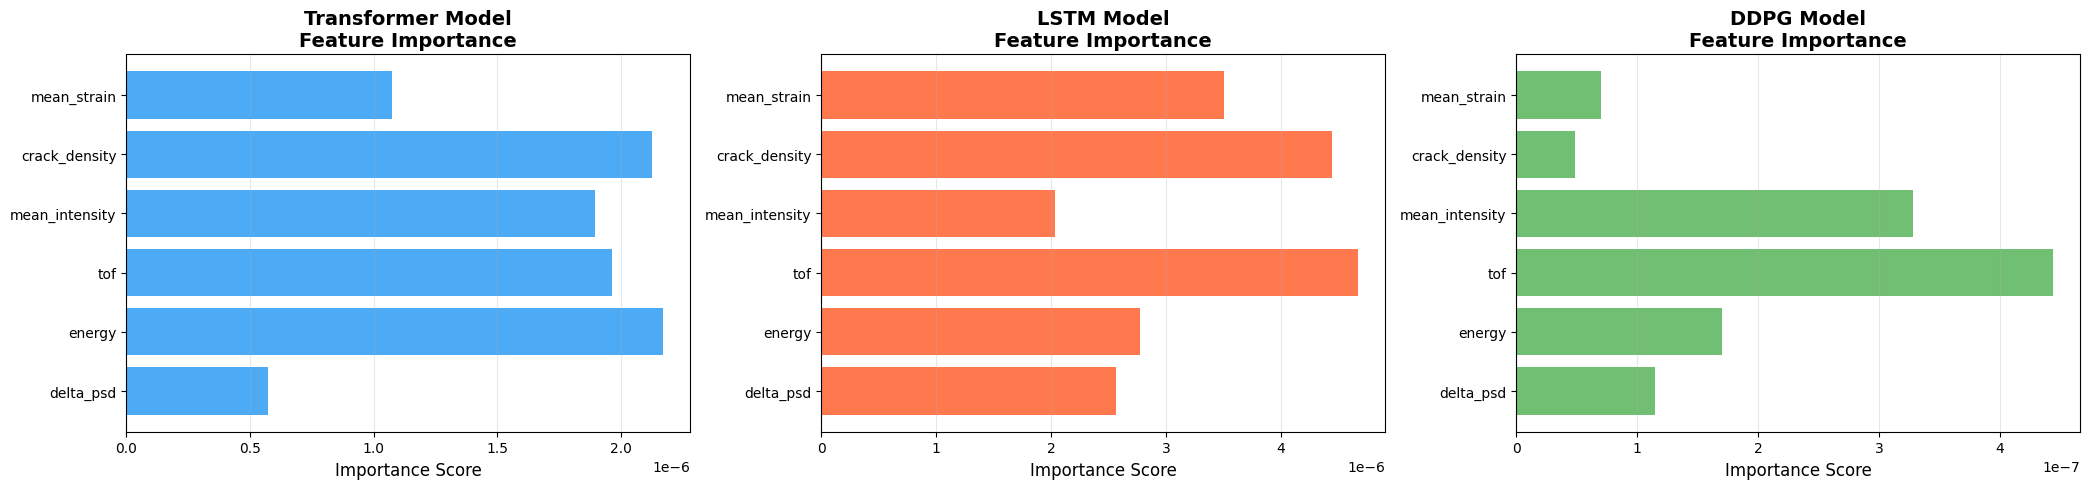


Feature Importance Comparison:
Feature              Transformer     LSTM            DDPG           
delta_psd            0.0000          0.0000          0.0000         
energy               0.0000          0.0000          0.0000         
tof                  0.0000          0.0000          0.0000         
mean_intensity       0.0000          0.0000          0.0000         
crack_density        0.0000          0.0000          0.0000         
mean_strain          0.0000          0.0000          0.0000         


In [20]:
# Compare feature importance across models
num_models = 3
fig, axes = plt.subplots(1, num_models, figsize=(7*num_models, 5))

if num_models == 2:
    axes = [axes[0], axes[1]]

# Transformer
features = list(transformer_exp['feature_importance'].keys())
importances_t = [transformer_exp['feature_importance'][f] for f in features]
axes[0].barh(features, importances_t, color='#2196F3', alpha=0.8)
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].set_title('Transformer Model\nFeature Importance', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# LSTM
importances_l = [lstm_exp['feature_importance'][f] for f in features]
axes[1].barh(features, importances_l, color='#FF5722', alpha=0.8)
axes[1].set_xlabel('Importance Score', fontsize=12)
axes[1].set_title('LSTM Model\nFeature Importance', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)


importances_d = [ddpg_exp['feature_importance'][f] for f in features]
axes[2].barh(features, importances_d, color='#4CAF50', alpha=0.8)
axes[2].set_xlabel('Importance Score', fontsize=12)
axes[2].set_title('DDPG Model\nFeature Importance', fontsize=14, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison
print("\nFeature Importance Comparison:")
print(f"{'Feature':<20} {'Transformer':<15} {'LSTM':<15} {'DDPG':<15}")
print("="*80)
for feature in features:
    t_imp = transformer_exp['feature_importance'][feature]
    l_imp = lstm_exp['feature_importance'][feature]
    d_imp = ddpg_exp['feature_importance'][feature]
    print(f"{feature:<20} {t_imp:<15.4f} {l_imp:<15.4f} {d_imp:<15.4f}")

## 7. Interactive Sample Explorer

Create an interactive widget to explore explanations for different samples.

In [21]:
from ipywidgets import interact, IntSlider, Dropdown

def explore_sample(sample_idx, model_choice):
    """Interactive function to explore different samples"""
    
    sample_sequence = X_test[sample_idx]
    actual_rul = y_test[sample_idx]
    
    # Select explainer and color
    if model_choice == 'Transformer':
        explainer = transformer_explainer
        color = '#2196F3'
    elif model_choice == 'LSTM':
        explainer = lstm_explainer
        color = '#FF5722'
    elif model_choice == 'DDPG':
        explainer = ddpg_explainer
        color = '#4CAF50'
    else:
        print(f"Model {model_choice} not available")
        return
    
    # Generate explanation
    exp = explainer.explain_prediction(sample_sequence, actual_rul, device, target_scaler)
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Feature importance
    features = list(exp['feature_importance'].keys())
    importances = [exp['feature_importance'][f] for f in features]
    axes[0].barh(features, importances, color=color, alpha=0.8)
    axes[0].set_xlabel('Importance Score', fontsize=12)
    axes[0].set_title(f'{model_choice} - Feature Importance', fontsize=13, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    
    # Prediction info
    axes[1].axis('off')
    info_text = f"""
    MODEL: {model_choice}
    
    PREDICTION:
    • Predicted RUL: {exp['predicted_rul']:.0f} cycles
    • Actual RUL: {exp['actual_rul']:.0f} cycles
    • Error: {exp['error']:.0f} cycles ({exp['error_percent']:.1f}%)
    
    TOP 3 FEATURES:
    """
    for i, (feat, imp) in enumerate(exp['top_features'][:3], 1):
        info_text += f"\n    {i}. {feat}: {imp:.4f}"
    
    info_text += "\n\n    KG EXPLANATIONS:\n"
    if exp['kg_explanations']:
        for i, kg_exp in enumerate(exp['kg_explanations'][:2], 1):
            info_text += f"\n    {i}. {kg_exp}\n"
    else:
        info_text += "\n    (No direct paths found)"
    
    axes[1].text(0.1, 0.5, info_text, fontsize=11, verticalalignment='center',
                family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.show()

# Create interactive widget with DDPG option
model_options = ['Transformer', 'LSTM', 'DDPG']

interact(
    explore_sample,
    sample_idx=IntSlider(min=0, max=len(X_test)-1, value=10, description='Sample:'),
    model_choice=Dropdown(options=model_options, value='DDPG', description='Model:')
);

interactive(children=(IntSlider(value=10, description='Sample:', max=59), Dropdown(description='Model:', index…